1. Import Libraried

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

2. Load Dataset(Fashion MNIST)

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


3. Normalize Data

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

4. Visualize Sample Images

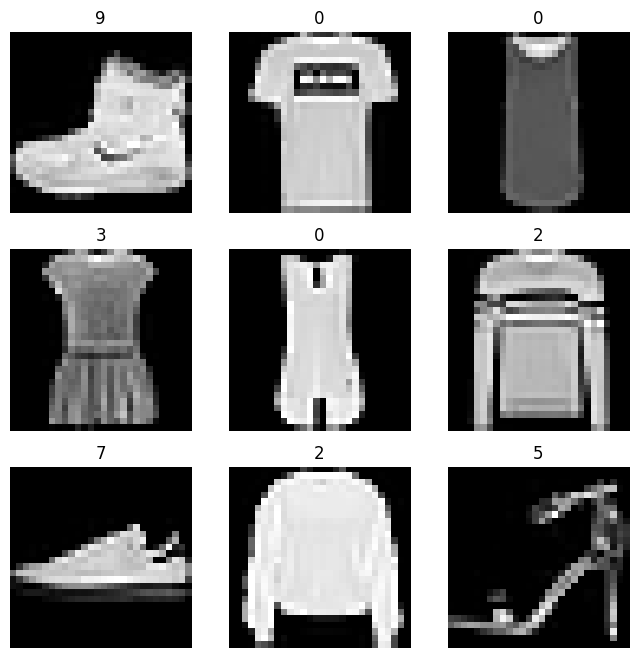

In [ ]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

Task 1 . Activation Function Change

In [ ]:
model_sigmoid = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_relu = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

TASK 2: Change Learning Rate

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_relu.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
history = model_relu.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9137 - loss: 0.2320 - val_accuracy: 0.8828 - val_loss: 0.3413
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9151 - loss: 0.2260 - val_accuracy: 0.8834 - val_loss: 0.3395
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9172 - loss: 0.2192 - val_accuracy: 0.8816 - val_loss: 0.3587
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9201 - loss: 0.2118 - val_accuracy: 0.8842 - val_loss: 0.3387
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9224 - loss: 0.2054 - val_accuracy: 0.8771 - val_loss: 0.3666


In [ ]:
history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9098 - loss: 0.2450 - val_accuracy: 0.8796 - val_loss: 0.3329
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9129 - loss: 0.2372 - val_accuracy: 0.8806 - val_loss: 0.3369
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9152 - loss: 0.2288 - val_accuracy: 0.8820 - val_loss: 0.3201
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9187 - loss: 0.2216 - val_accuracy: 0.8878 - val_loss: 0.3154
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9209 - loss: 0.2147 - val_accuracy: 0.8850 - val_loss: 0.3193


Plot Accuracy & Loss

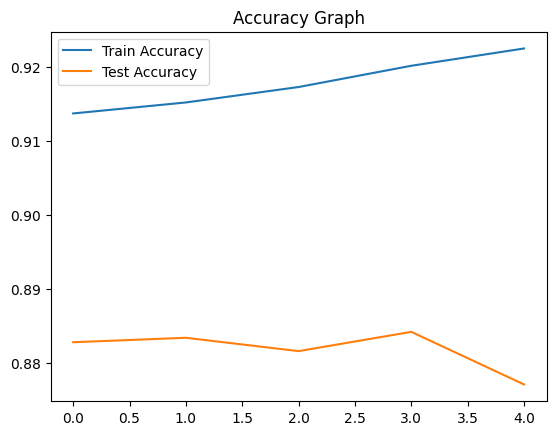

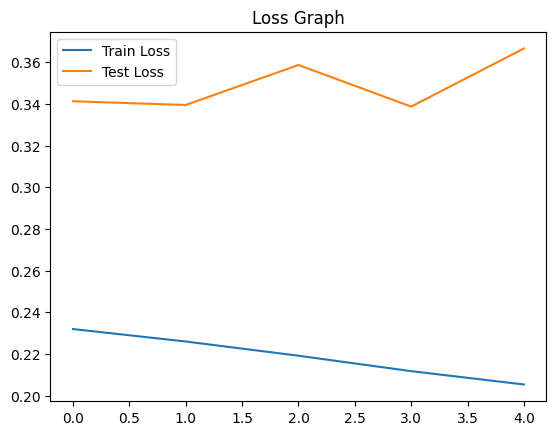

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

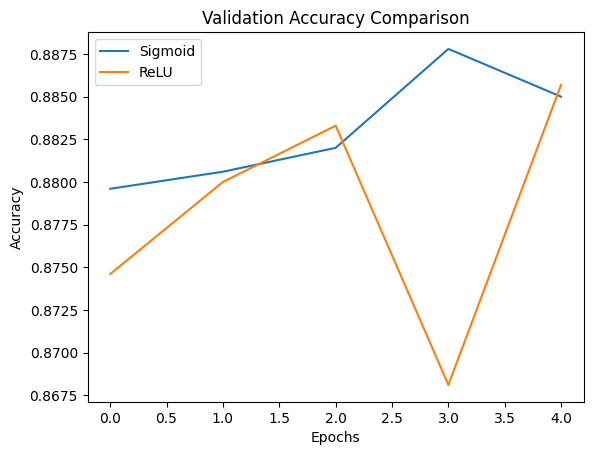

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_relu.history['val_accuracy'], label='ReLU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

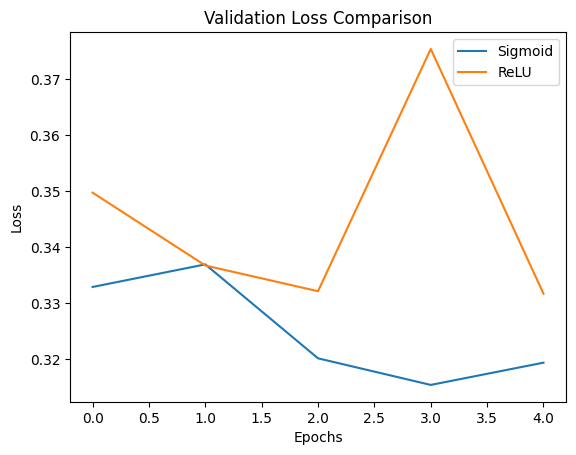

In [ ]:
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(history_relu.history['val_loss'], label='ReLU')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

Predict New Input

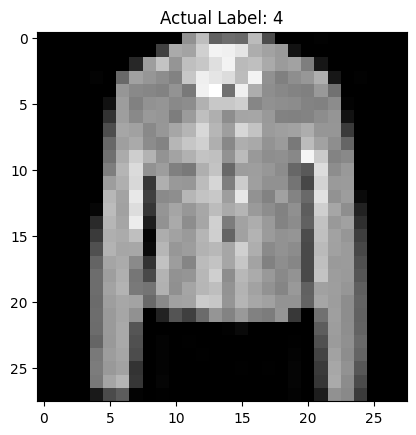

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Label: 4


In [ ]:
index = 10
sample = X_test[index]

plt.imshow(sample, cmap='gray')
plt.title("Actual Label: " + str(y_test[index]))
plt.show()

sample = np.expand_dims(sample, axis=0)

prediction = model_relu.predict(sample)

predicted_label = np.argmax(prediction)

print("Predicted Label:", predicted_label)

Class Labels

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Predicted:", class_names[predicted_label])

Predicted: Coat


Evaluate on Test Data

In [ ]:
test_loss, test_acc = model_relu.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8857 - loss: 0.3317
Test Accuracy: 0.885699987411499
Test Loss: 0.33165282011032104


Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


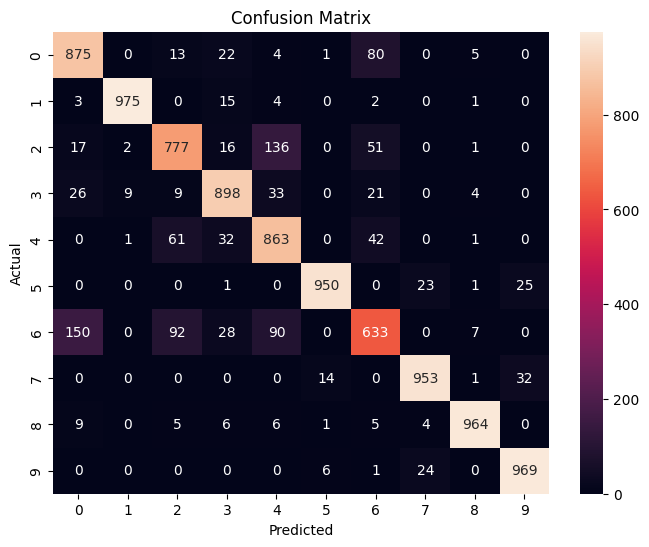

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model_relu.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Use Better Model (CNN)

In [ ]:
model_cnn = models.Sequential([
    layers.Reshape((28,28,1), input_shape=(28,28)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile & Train

In [ ]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8364 - loss: 0.4495 - val_accuracy: 0.8744 - val_loss: 0.3555
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.8916 - loss: 0.2961 - val_accuracy: 0.8925 - val_loss: 0.2892
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9073 - loss: 0.2487 - val_accuracy: 0.9021 - val_loss: 0.2663
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9192 - loss: 0.2171 - val_accuracy: 0.9055 - val_loss: 0.2654
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 20ms/step - accuracy: 0.9270 - loss: 0.1925 - val_accuracy: 0.8994 - val_loss: 0.2736
